In [1]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
df = df.dropna(subset=['CustomerID'])

In [3]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [4]:
df = df[df['Quantity'] > 0]

df = df[df['UnitPrice'] > 0]

In [5]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [6]:
customer_df = df.groupby('CustomerID').agg({
    'Revenue':'sum',
    'InvoiceNo':'nunique',
    'Quantity':'sum'
}).reset_index()

In [8]:
customer_df.columns = [
    'CustomerID',
    'CLV',
    'Frequency',
    'TotalQuantity'
]

In [9]:
customer_df['AvgOrderValue'] = (
    customer_df['CLV'] /
    customer_df['Frequency']
)

In [10]:
X = customer_df[
    ['Frequency',
     'TotalQuantity',
     'AvgOrderValue']
]

y = customer_df['CLV']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [13]:
y_pred = model.predict(X_test)

In [14]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

print("MAE:",
      mean_absolute_error(y_test,y_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(
          y_test,y_pred
      )))

print("R2:",
      r2_score(y_test,y_pred))

MAE: 454.3121797119814
RMSE: 5091.470500953487
R2: 0.7469508468140067


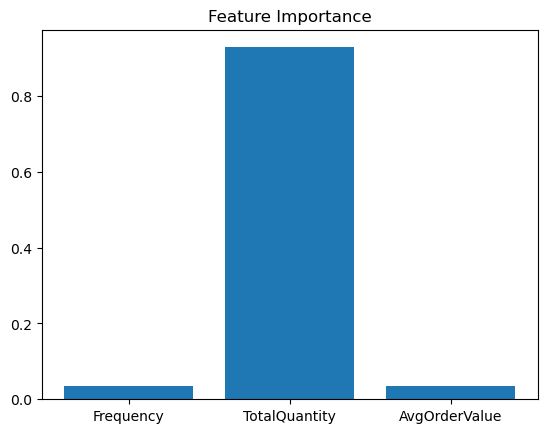

In [15]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.bar(
    X.columns,
    importance
)

plt.title(
    "Feature Importance"
)

plt.show()

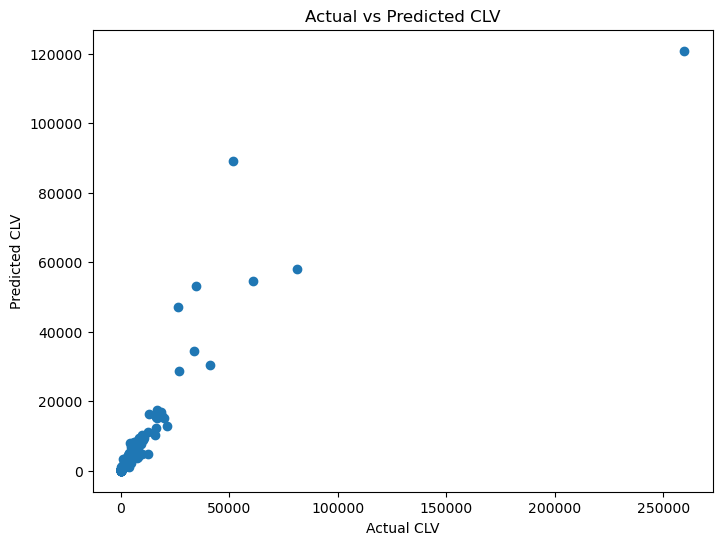

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual CLV")

plt.ylabel("Predicted CLV")

plt.title("Actual vs Predicted CLV")

plt.show()

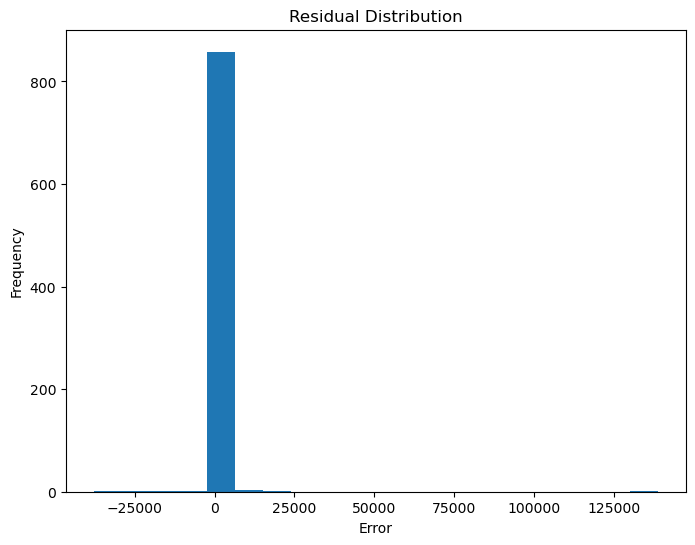

In [17]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.hist(residuals, bins=20)

plt.title("Residual Distribution")

plt.xlabel("Error")

plt.ylabel("Frequency")

plt.show()

In [18]:
new_customer = [[10, 200, 50]]

prediction = model.predict(new_customer)

print("Predicted CLV =", prediction[0])

Predicted CLV = 467.08520000000027


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [19]:
import joblib

joblib.dump(model, "clv_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [20]:
loaded_model = joblib.load("clv_model.pkl")

prediction = loaded_model.predict(new_customer)

print(prediction)

[467.0852]


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [21]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance_df.sort_values(
    by='Importance',
    ascending=False,
    inplace=True
)

print(importance_df)

         Feature  Importance
1  TotalQuantity    0.928843
2  AvgOrderValue    0.036029
0      Frequency    0.035128


Conclusion

This project successfully predicts Customer Lifetime Value (CLV) using machine learning techniques.

The Random Forest Regression model was trained using customer purchasing behavior and achieved satisfactory predictive performance.

The model can help businesses:
- Identify high-value customers
- Improve customer retention
- Optimize marketing expenditure
- Forecast future revenue

Thus, Customer Lifetime Value Prediction serves as an important tool for customer relationship management and business growth.